In [1]:
#Purpose
#analysing rising sea level trends in the Pacific and assessing the projected impact on low-lying nations

#Importing Libraries
library(tidyverse)
library(ggplot2)
library(reshape2)

Warning message:
"package 'ggplot2' was built under R version 4.5.3"
── Attaching core tidyverse packages ─────────────────────────────────────────────────────────────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ───────────────────────────────────────────────────────────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
Warning message:
"package 'reshape2' was built under R version 4.5.3"

Attaching package: 'reshape2'


The following object is masked from 'package:tidyr':

    smiths




In [2]:
#Importing dataset and inspection
main_df <- read.csv("fixed_cleaned_Tuvalu_sea_level_clean.csv")
glimpse(main_df) #shows every column name and it's data type and preview of actual values. Used instead of head() and str().

Rows: 520
Columns: 6
$ Year         <int> 1977, 1977, 1978, 1978, 1978, 1978, 1978, 1978, 1978, 197…
$ Month        <int> 11, 12, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 1, 3, 5, 6…
$ Monthly_MSL  <dbl> 6.919, 6.875, 6.829, 6.887, 6.921, 7.011, 7.013, 7.029, 7…
$ Linear_Trend <dbl> 6.923, 6.924, 6.924, 6.924, 6.925, 6.925, 6.925, 6.926, 6…
$ High_Conf    <dbl> 6.961, 6.961, 6.962, 6.962, 6.962, 6.962, 6.963, 6.963, 6…
$ Low_Conf     <dbl> 6.886, 6.886, 6.886, 6.887, 6.887, 6.888, 6.888, 6.888, 6…


In [3]:
summary(main_df)

      Year          Month         Monthly_MSL     Linear_Trend  
 Min.   :1977   Min.   : 1.000   Min.   :6.576   Min.   :6.923  
 1st Qu.:1989   1st Qu.: 3.000   1st Qu.:6.967   1st Qu.:6.967  
 Median :2000   Median : 6.000   Median :7.016   Median :6.992  
 Mean   :2000   Mean   : 6.502   Mean   :7.000   Mean   :6.999  
 3rd Qu.:2011   3rd Qu.:10.000   3rd Qu.:7.055   3rd Qu.:7.035  
 Max.   :2023   Max.   :12.000   Max.   :7.184   Max.   :7.080  
   High_Conf        Low_Conf    
 Min.   :6.961   Min.   :6.886  
 1st Qu.:6.993   1st Qu.:6.940  
 Median :7.016   Median :6.969  
 Mean   :7.028   Mean   :6.971  
 3rd Qu.:7.062   3rd Qu.:7.007  
 Max.   :7.117   Max.   :7.042  

[1] "Histogram saved"


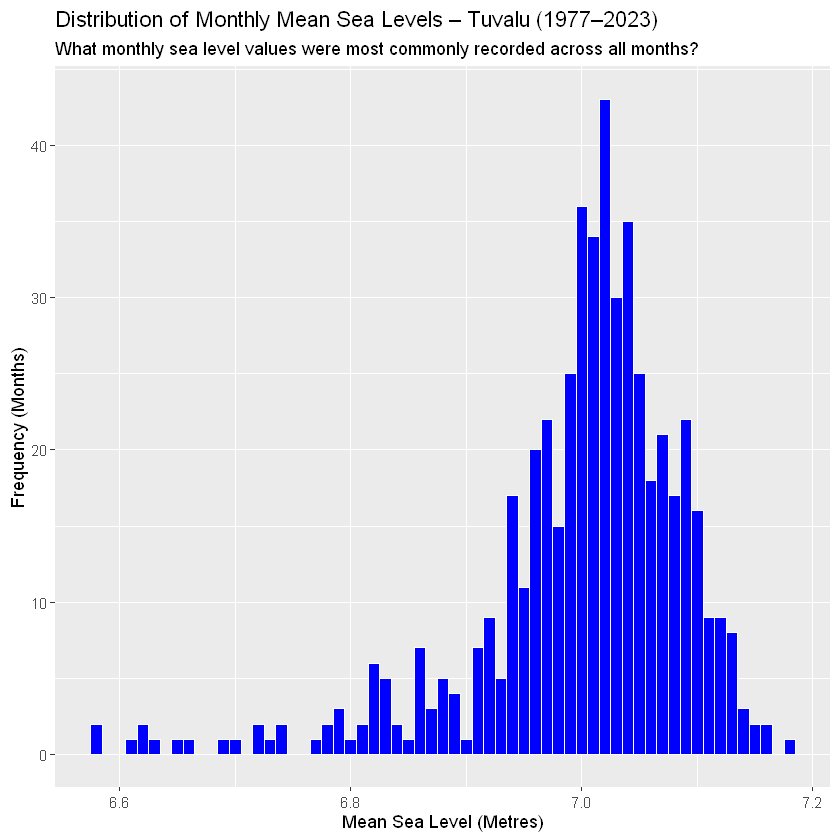

In [4]:
#Step 2 Visualising the Monthly Sea Level values of Tuvalu
ggplot(data = main_df, aes(x = Monthly_MSL)) + #Maps monthly sea level values to visualise it's distribution across the months sea levels have been recorded
geom_histogram(binwidth = 0.01, fill = "blue", colour = "white") + #Binwidth 0.01 chosen to reveal neat distribution shape without bars becoming too narrow.
labs(
    title = "Distribution of Monthly Mean Sea Levels – Tuvalu (1977–2023)",
    subtitle = "What monthly sea level values were most commonly recorded across all months?",
    y = "Frequency (Months)", #represents the number of months that fall within each sea level bin.
    x = "Mean Sea Level (Metres)" #
    )

ggsave("Tuvalu_sea_level_histogram.png", width = 7, height = 5) #Exporting histogram into a png format
print("Histogram saved")

In [5]:
#Peak (Most Common Value)
#The tallest bar sits around 7.02–7.03m, reaching a frequency of ~43 months. This means that sea level value was recorded more often than any other across the 46-year record.

#Shape - Right Skew (Positive Skew)
#Distribution is not symmetrical. In earlier years of the observations, lower sea level readings were less common but did occur.

In [6]:
#Step 2.1 Calculating the mean and standard deviation of the Monthly Sea Level values
mean_monthly_MSL <- mean(main_df$Monthly_MSL)
print(mean_monthly_MSL)

sd_monthly_MSL <- sd(main_df$Monthly_MSL)
print(sd_monthly_MSL)

range(main_df$Monthly_MSL) #For seq()

[1] 6.999517
[1] 0.09292336


[1] 6.576 7.184

[1] "Histogram + Normal Curve saved"


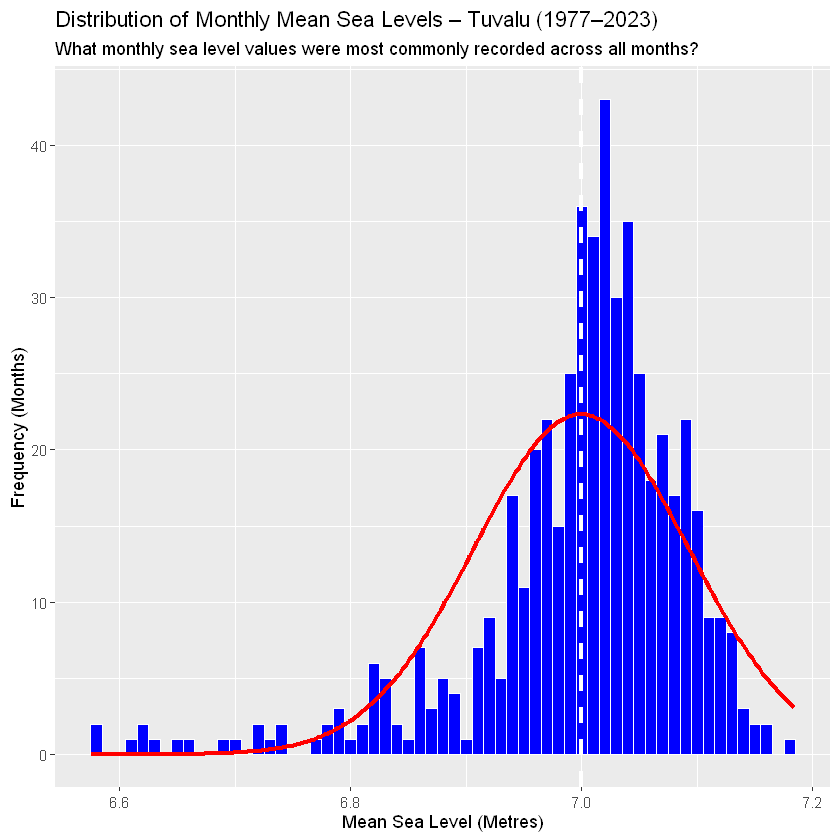

In [7]:
#Step 2.2 - Generating a normal distribution and overlaying over the histogram
# Create x-values for the curve
x <- seq(6.576, 7.184, length.out = 200) # The start and end points of the data, so needs to match data's actual range

# Generate y-values using the density function
y <- dnorm(x, mean = mean_monthly_MSL, sd = sd_monthly_MSL) * nrow(main_df) * 0.01 #converts the density values into the same frequency scale as the
# histogram bars, so the curve sits correctly on top of the plot.

# Create data frame
line_overlay_df <- data.frame(x, y)

ggplot(data = main_df, aes(x = Monthly_MSL)) + #Maps monthly sea level values to visualise it's distribution across the months sea levels have been recorded
geom_histogram(binwidth = 0.01, fill = "blue", colour = "white") + #Binwidth 0.01 chosen to reveal neat distribution shape without bars becoming too narrow.
labs(
    title = "Distribution of Monthly Mean Sea Levels – Tuvalu (1977–2023)",
    subtitle = "What monthly sea level values were most commonly recorded across all months?",
    y = "Frequency (Months)", #represents the number of months that fall within each sea level bin.
    x = "Mean Sea Level (Metres)" #
    ) + 
  geom_line(data = line_overlay_df, aes(x = x, y =y), color = "red", linewidth = 1.2) + #Draws the continuous bell curve line
    #Adds title and axis labels
    geom_vline(xintercept = mean_monthly_MSL, linetype = "dashed", color = "white", linewidth=1.2) #geom_vline draws a vertical line. #xintercept places it at the expected value 


ggsave("Tuvalu_sea_level_histogram_with_normal_curve.png", width = 7, height = 5) #Exporting histogram into a png format
print("Histogram + Normal Curve saved")

In [8]:
#Red normal curve peaks ~7.0m and geom_vline places it at expected value of 7.0 vs. the tallest histogram bar is around 7.02-7.03m
#Shows that this data is not perfectly normally dsitributed
#Suggests sea levels in Tuvalu have been rising over time, , pulling older lower readings away from the modern cluster, which is why the distribution is skewed rather than normal.

In [9]:
#Step 2.3 - Calculating the probability a monthly sea level reading exceeds 120mm (0.12mm).
probability_exceeding_120 <- pnorm(mean_monthly_MSL + 0.12, mean = mean_monthly_MSL, sd = sd_monthly_MSL, lower.tail = FALSE) #120mm -> 0.12m.
probability_exceeding_120 

[1] 0.0982848

In [10]:
print(round(probability_exceeding_120 * 100, 2)) # the probability that any single month will record a sea level exceeding 120mm above the mean

[1] 9.83


In [11]:
#Calculating the amount of exceedances past the mean per year using Binomial Expected Value 
#E[X] = n x p

#Defining parameters
n = 12 #Number of months in a year
p = probability_exceeding_120  #Probability of the event of sea level exceeding the mean 7.0

#Calculation
exceedances_per_year <- n * p
print(round(exceedances_per_year, 2)) #he expected number of months per year where that threshold is crossed

[1] 1.18


In [12]:
#A 9.81% monthly probability of sea levels exceeding 120mm above the mean equates to approximately 1.18 months per year where this threshold is crossed. For a low-lying nation like Tuvalu, whose highest point is only 4.6 metres above sea level ((“Geography of Tuvalu,” 2026)), even brief exceedances above the mean pose a significant risk of coastal flooding and inundation.